In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt 

reliance = yf.download("reliance.ns",period="1y")
tcs=yf.download("tcs.ns",period="1y")
reliance.head()
tcs.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2025-06-30,3330.932129,3333.722244,3300.143617,3309.668719,1468351
2025-07-01,3299.854736,3353.061177,3284.268100,3324.196949,2375183
2025-07-02,3293.697266,3357.775714,3290.522153,3355.177980,3090585
2025-07-03,3272.049316,3305.243182,3268.970512,3300.143788,2531870
2025-07-04,3290.329834,3297.257202,3261.754293,3278.976523,1109320


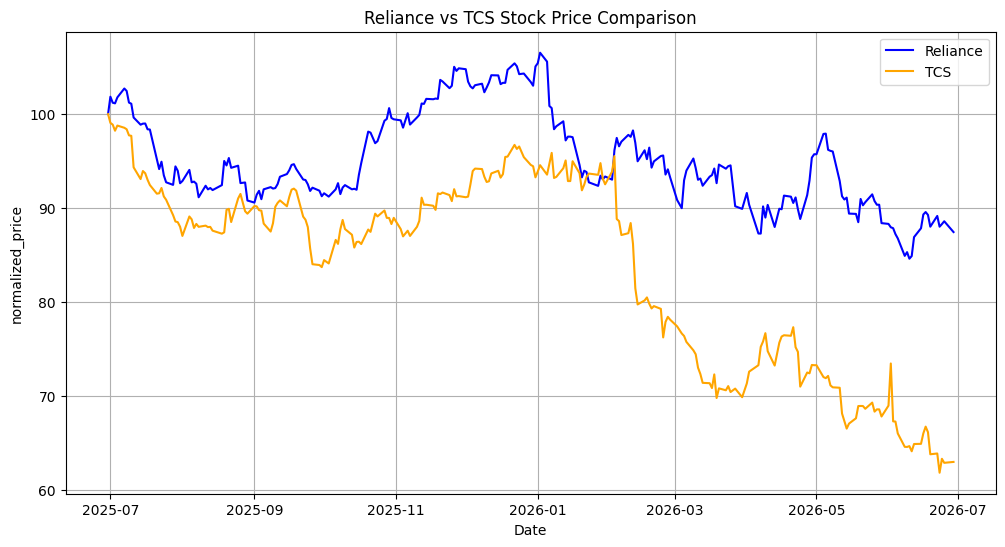

In [3]:
reliance_normalized=(reliance['Close']/reliance['Close'].iloc[0])*100
tcs_normalized=(tcs['Close']/tcs['Close'].iloc[0])*100
plt.figure(figsize=(12,6))
plt.plot(reliance_normalized,label='Reliance',color='blue')
plt.plot(tcs_normalized,label='TCS',color='orange')
plt.xlabel("Date")
plt.ylabel("normalized_price")
plt.title("Reliance vs TCS Stock Price Comparison")
plt.legend()
plt.grid(True)
plt.show()

tcs daily return: Ticker
TCS.NS   -0.001745
dtype: float64
TCS volatility: Ticker
TCS.NS    0.01577
dtype: float64
Reliance daily return: Ticker
RELIANCE.NS   -0.000462
dtype: float64
Reliance volatility: Ticker
RELIANCE.NS    0.012706
dtype: float64


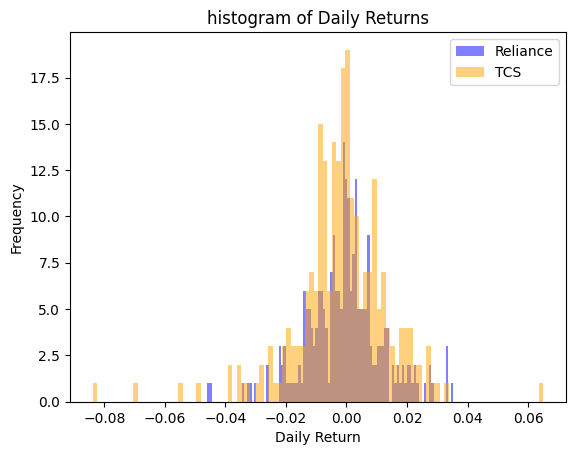

In [4]:
reliance_return=reliance['Close'].pct_change().dropna()
tc_return=tcs['Close'].pct_change().dropna()
print("tcs daily return:",tc_return.mean())
print("TCS volatility:",tc_return.std())
print("Reliance daily return:",reliance_return.mean())
print("Reliance volatility:",reliance_return.std())
plt.hist(reliance_return,bins=100,alpha=0.5,label='Reliance',color='blue')
plt.hist(tc_return,bins=100,alpha=0.5,label='TCS',color='orange')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.title("histogram of Daily Returns")
plt.legend()
plt.show()


In [5]:
returns = pd.DataFrame({'Reliance': reliance_return.squeeze(), 'TCS': tc_return.squeeze()})

In [6]:
returns.corr()

,Reliance,TCS
Reliance,1.000000,0.206256
TCS,0.206256,1.000000


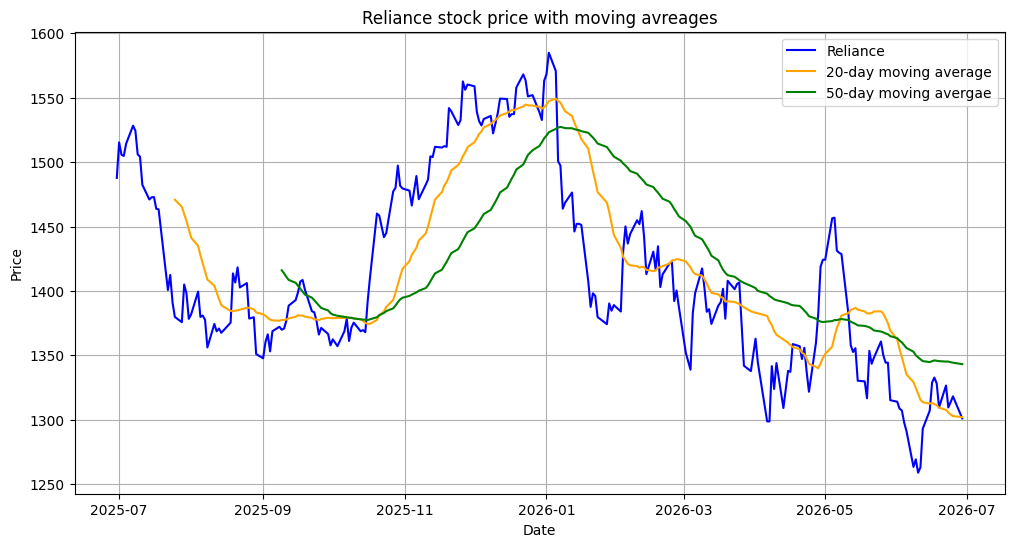

In [7]:
reliance_moving_avg20=reliance['Close'].rolling(window=20).mean()
reliance_moving_avg50=reliance['Close'].rolling(window=50).mean()
plt.figure(figsize=(12,6))
plt.plot(reliance['Close'],label='Reliance',color='blue')
plt.plot(reliance_moving_avg20,label='20-day moving average',color='orange')
plt.plot(reliance_moving_avg50,label='50-day moving avergae',color='green')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Reliance stock price with moving avreages')
plt.legend()
plt.grid(True)
plt.show()


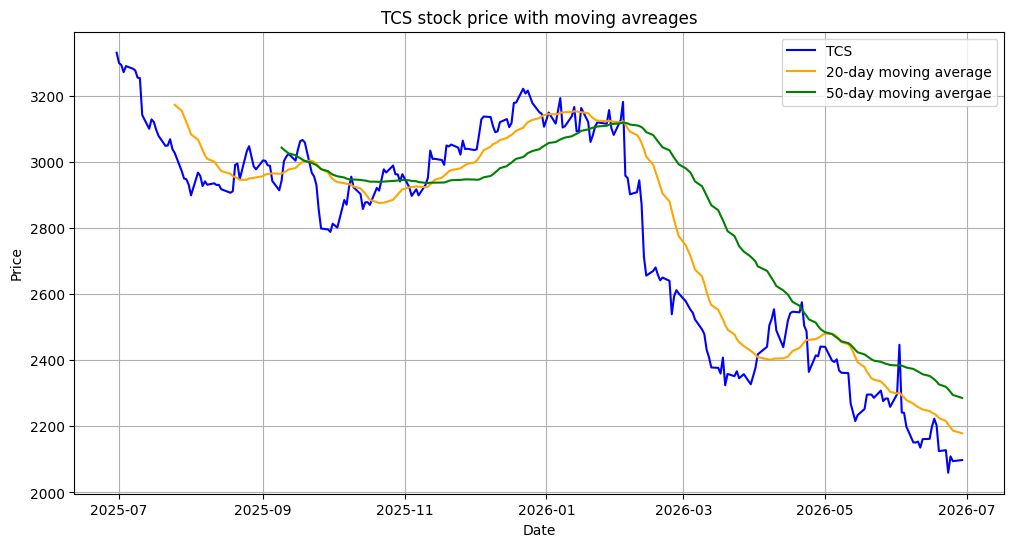

In [8]:
tcs_moving_avg20=tcs['Close'].rolling(window=20).mean()
tcs_moving_avg50=tcs['Close'].rolling(window=50).mean()
plt.figure(figsize=(12,6))
plt.plot(tcs['Close'],label='TCS',color='blue')
plt.plot(tcs_moving_avg20,label='20-day moving average',color='orange')
plt.plot(tcs_moving_avg50,label='50-day moving avergae',color='green')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('TCS stock price with moving avreages')
plt.legend()
plt.grid(True)
plt.show()


In [9]:
risk_free_rate=0.06/252
reliance_sharpe_ratio=(reliance_return.mean()-risk_free_rate)/reliance_return.std()
tcs_sharpe_ratio=(tc_return.mean()-risk_free_rate)/tc_return.std()
print("Reliance Sharpe Ratio:",reliance_sharpe_ratio)
print("TCS Sharpe Ratio:",tcs_sharpe_ratio)

Reliance Sharpe Ratio: Ticker
RELIANCE.NS   -0.055126
dtype: float64
TCS Sharpe Ratio: Ticker
TCS.NS   -0.125733
dtype: float64


In [11]:
reliance_rolling_max=reliance['Close'].cummax()
drawdown=(reliance['Close']-reliance_rolling_max)/reliance_rolling_max
drawdown_maxdrawdown=drawdown.min()
print("Reliance Max Drawdown:",drawdown_maxdrawdown)

Reliance Max Drawdown: Ticker
RELIANCE.NS   -0.20579
dtype: float64


In [14]:
tcs_rolling_max=tcs['Close'].cummax()
drawdown_tcs=(tcs['Close']-tcs_rolling_max)/tcs_rolling_max
drawdown_maxdrawdown_tcs=drawdown_tcs.min()
print("tcs maximum drawdown:",drawdown_maxdrawdown_tcs)

tcs maximum drawdown: Ticker
TCS.NS   -0.381675
dtype: float64


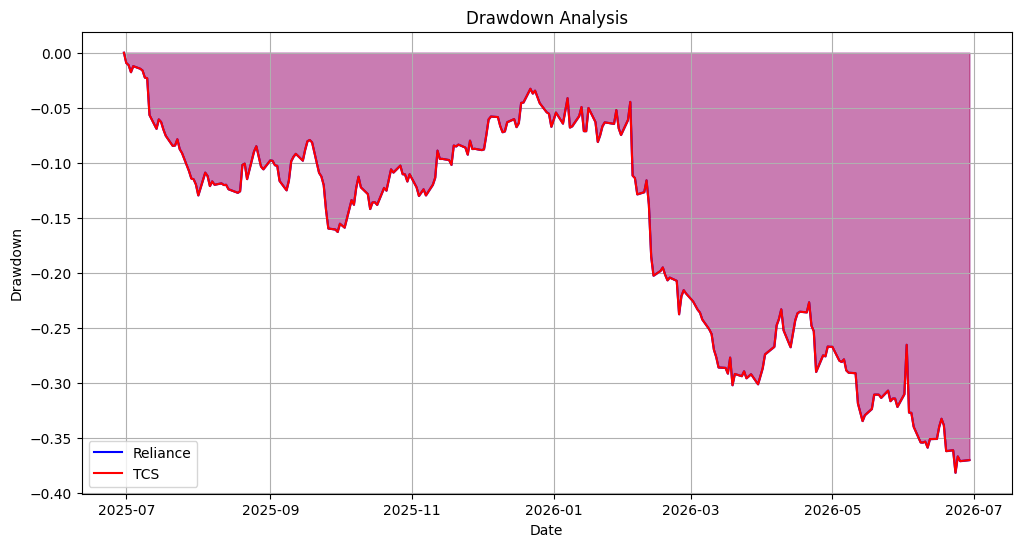

In [20]:
drawdown_squeezed=drawdown.squeeze()
drawdown_tcs_squeezed=drawdown_tcs.squeeze()
plt.figure(figsize=(12,6))
plt.plot(drawdown,label='Reliance',color='blue')
plt.plot(drawdown_tcs,label="TCS",color='red')
plt.title("Drawdown Analysis")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.fill_between(drawdown.index,drawdown_squeezed,0,color='blue',alpha=0.3)
plt.fill_between(drawdown_tcs.index,drawdown_tcs_squeezed,0,color='red',alpha=0.3)
plt.legend()
plt.grid(True)
plt.show()